<a href="https://colab.research.google.com/github/ntwdtlari/AULA-INTELIGENCIA-ARTIFICIAL/blob/main/Aula_11_dengue_Larissa_Lemes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Casos de Dengue no Brasil

In [ ]:
# Bibliotecas essenciais para ciência de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='Set2')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [6]:
# Carregar os dados
df = pd.read_csv('/content/DENGBR26.csv',
                 encoding='latin1',
                 low_memory=False)

# Visualizar primeiras linhas
df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495.0,2026-01-04,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
1,2,A90,2026-01-05,202601,2026,32,320520,32002,4676874.0,2026-01-05,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772.0,2026-01-05,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131.0,2026-01-04,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0
4,2,A90,2026-01-05,202601,2026,32,320530,32002,11789.0,2026-01-05,...,0.0,0.0,0.0,0.0,0.0,0.0,2026-01-05,0,0.0,0.0


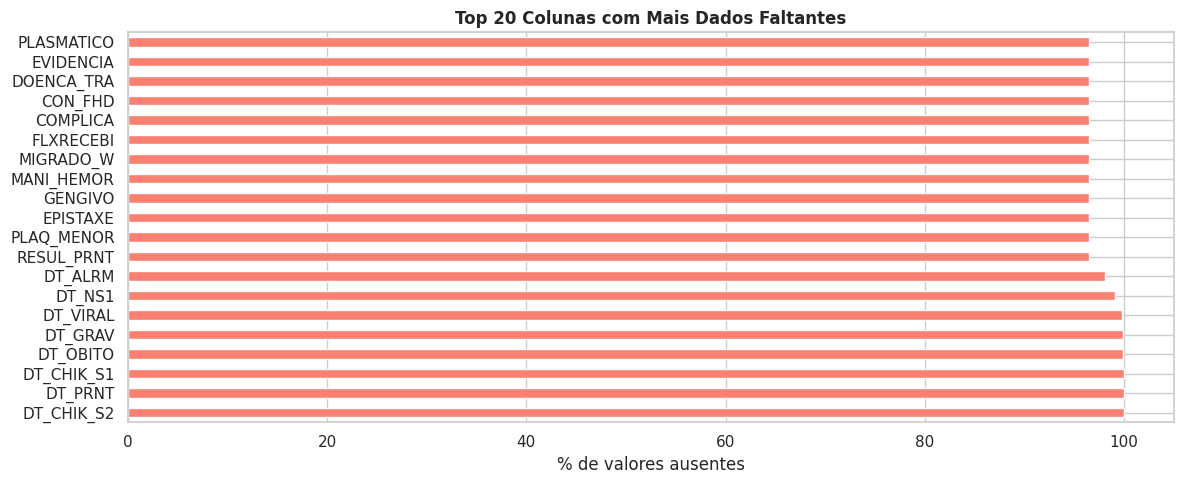

68 colunas possuem mais de 50% de dados ausentes


In [7]:
# Percentual de valores ausentes
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_top = missing[missing > 0].head(20)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))

missing_top.plot(kind='barh',
                 ax=ax,
                 color='salmon')

ax.set_xlabel('% de valores ausentes')
ax.set_title('Top 20 Colunas com Mais Dados Faltantes',
             fontweight='bold')

plt.tight_layout()
plt.show()

print(f'{(missing > 50).sum()} colunas possuem mais de 50% de dados ausentes')


## Análise Exploratória de Dados

In [ ]:
# Converter datas e criar coluna de mês
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['MES_NOT'] = df['DT_NOTIFIC'].dt.month
df['SEM_NOT_LABEL'] = df['SEM_NOT'].astype(str)

por_mes = df['MES_NOT'].value_counts().sort_index()
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots()
bars = ax.bar(por_mes.index, por_mes.values, color=sns.color_palette('Blues_d', len(por_mes)))
ax.set_xticks(por_mes.index)
ax.set_xticklabels([meses[i-1] for i in por_mes.index])
ax.set_xlabel('Mês')
ax.set_ylabel('Notificações')
ax.set_title('Notificações de Dengue por Mês (2026)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"🔺 Mês com maior número de notificações: {meses[por_mes.idxmax()-1]} ({por_mes.max():,} casos)")


### Distribuição por Estado

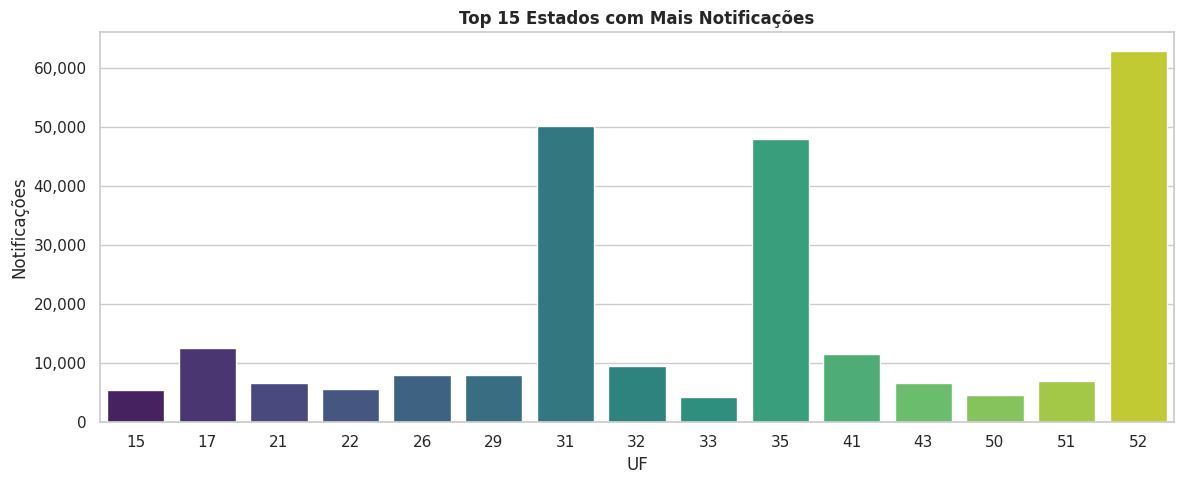

SG_UF_NOT
52    62960
31    50290
35    48021
17    12613
41    11629
Name: count, dtype: int64


In [9]:
# Casos por estado
por_uf = df['SG_UF_NOT'].value_counts().head(15)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(x=por_uf.index,
            y=por_uf.values,
            palette='viridis',
            ax=ax)

ax.set_xlabel('UF')
ax.set_ylabel('Notificações')

ax.set_title('Top 15 Estados com Mais Notificações',
             fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

print(por_uf.head())


### Perfil Demográfico

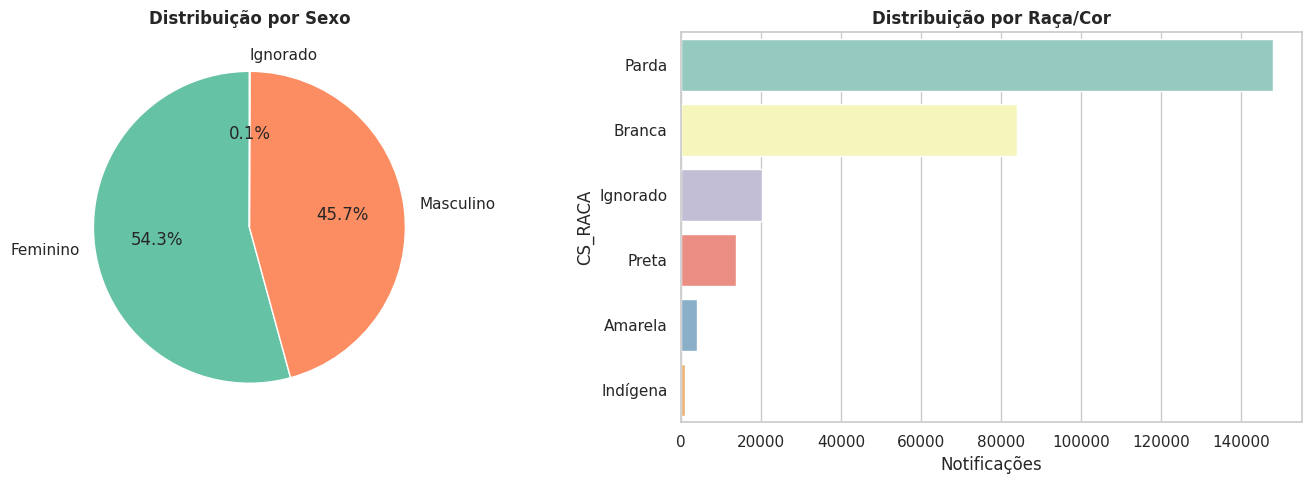

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sexo
sexo_map = {
    'M': 'Masculino',
    'F': 'Feminino',
    'I': 'Ignorado'
}

sexo = df['CS_SEXO'].map(sexo_map).value_counts()

axes[0].pie(sexo.values,
            labels=sexo.index,
            autopct='%1.1f%%',
            startangle=90)

axes[0].set_title('Distribuição por Sexo',
                  fontweight='bold')

# Raça/cor
raca_map = {
    1:'Branca',
    2:'Preta',
    3:'Amarela',
    4:'Parda',
    5:'Indígena',
    9:'Ignorado'
}

raca = df['CS_RACA'].map(raca_map).value_counts()

sns.barplot(x=raca.values,
            y=raca.index,
            palette='Set3',
            ax=axes[1])

axes[1].set_xlabel('Notificações')

axes[1].set_title('Distribuição por Raça/Cor',
                  fontweight='bold')

plt.tight_layout()
plt.show()

### Sintomas Mais Frequentes

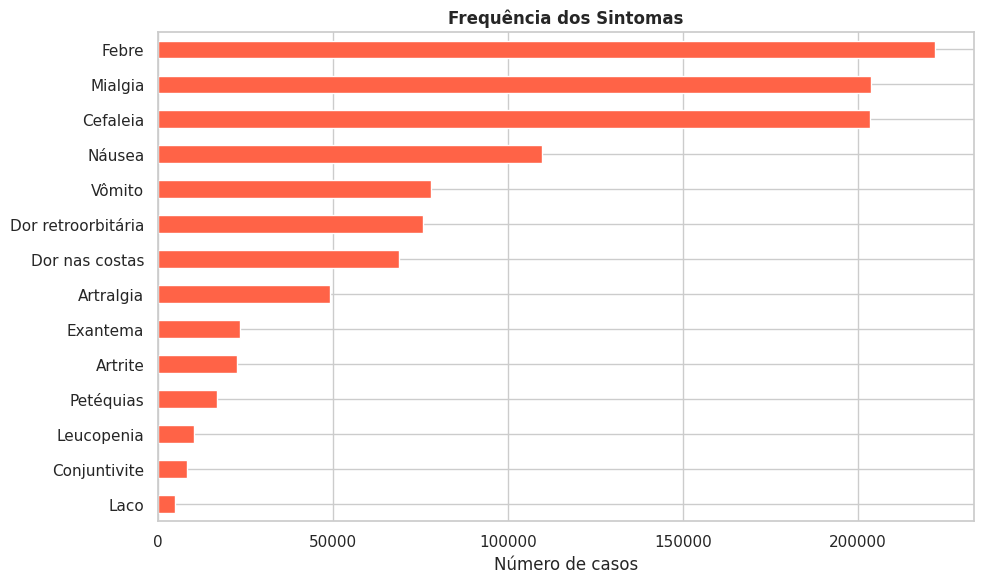

In [11]:
# Colunas de sintomas
sintomas_cols = [
    'FEBRE','MIALGIA','CEFALEIA',
    'EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT',
    'ARTRITE','ARTRALGIA',
    'PETEQUIA_N','LEUCOPENIA',
    'LACO','DOR_RETRO'
]

# Tradução dos nomes
sintomas_nomes = {
    'FEBRE':'Febre',
    'MIALGIA':'Mialgia',
    'CEFALEIA':'Cefaleia',
    'EXANTEMA':'Exantema',
    'VOMITO':'Vômito',
    'NAUSEA':'Náusea',
    'DOR_COSTAS':'Dor nas costas',
    'CONJUNTVIT':'Conjuntivite',
    'ARTRITE':'Artrite',
    'ARTRALGIA':'Artralgia',
    'PETEQUIA_N':'Petéquias',
    'LEUCOPENIA':'Leucopenia',
    'LACO':'Laco',
    'DOR_RETRO':'Dor retroorbitária'
}

# Frequência
freq_sint = {
    sintomas_nomes[c]:
    (df[c] == 1).sum()

    for c in sintomas_cols
    if c in df.columns
}

freq_sint = pd.Series(freq_sint)\
                .sort_values(ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

freq_sint.plot(kind='barh',
               color='tomato',
               ax=ax)

ax.set_xlabel('Número de casos')

ax.set_title('Frequência dos Sintomas',
             fontweight='bold')

plt.tight_layout()
plt.show()


### Hospitalização e Evolução

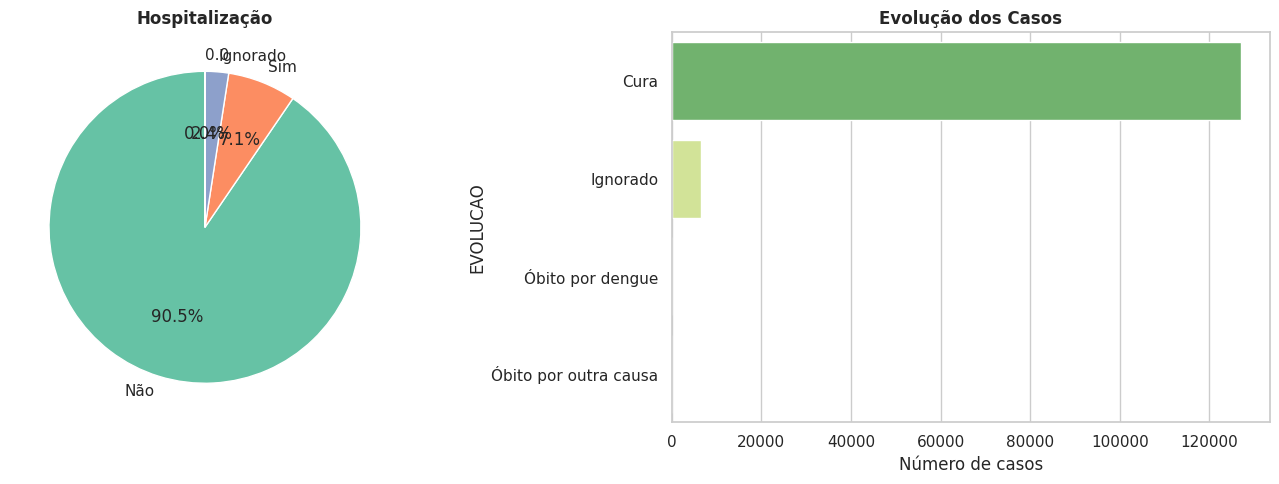

Óbitos confirmados: 91
Taxa de letalidade: 0.0336%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hospitalização
hosp = df['HOSPITALIZ'].value_counts()

hosp_map = {
    1:'Sim',
    2:'Não',
    9:'Ignorado'
}

hosp.index = [hosp_map.get(i, str(i))
              for i in hosp.index]

axes[0].pie(hosp.values,
            labels=hosp.index,
            autopct='%1.1f%%',
            startangle=90)

axes[0].set_title('Hospitalização',
                  fontweight='bold')

# Evolução
evolucao_map = {
    1:'Cura',
    2:'Óbito por dengue',
    3:'Óbito por outra causa',
    9:'Ignorado'
}

evol = df['EVOLUCAO'].map(evolucao_map)\
                     .value_counts()

sns.barplot(x=evol.values,
            y=evol.index,
            palette='RdYlGn_r',
            ax=axes[1])

axes[1].set_xlabel('Número de casos')

axes[1].set_title('Evolução dos Casos',
                  fontweight='bold')

plt.tight_layout()
plt.show()

# Taxa de letalidade
obitos = (df['EVOLUCAO'] == 2).sum()

total = len(df)

print(f'Óbitos confirmados: {obitos:,}')
print(f'Taxa de letalidade: {obitos/total*100:.4f}%')

### Classificação Final dos Casos

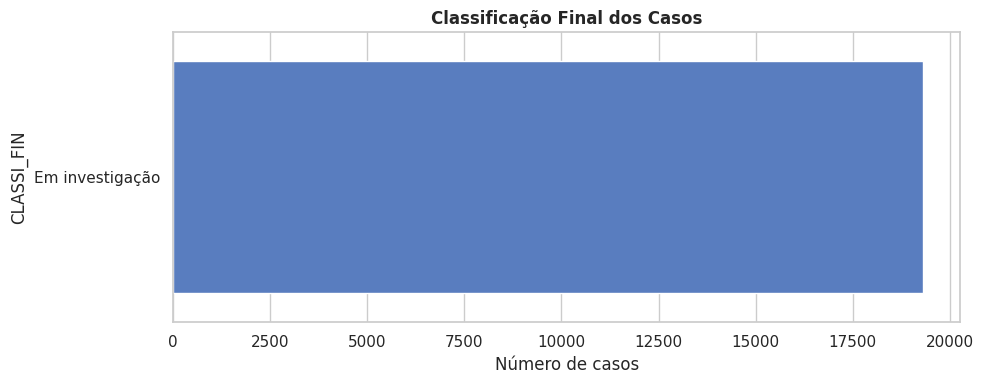

In [13]:
classi_map = {
    1: 'Dengue clássica',
    2: 'Dengue com complicação',
    3: 'Dengue grave',
    4: 'Descartado',
    5: 'Inconclusivo',
    8: 'Em investigação'
}

classi = df['CLASSI_FIN'].map(classi_map)\
                         .value_counts()

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(x=classi.values,
            y=classi.index,
            palette='muted',
            ax=ax)

ax.set_xlabel('Número de casos')

ax.set_title('Classificação Final dos Casos',
             fontweight='bold')

plt.tight_layout()
plt.show()

### Distribuição por Faixa Etária

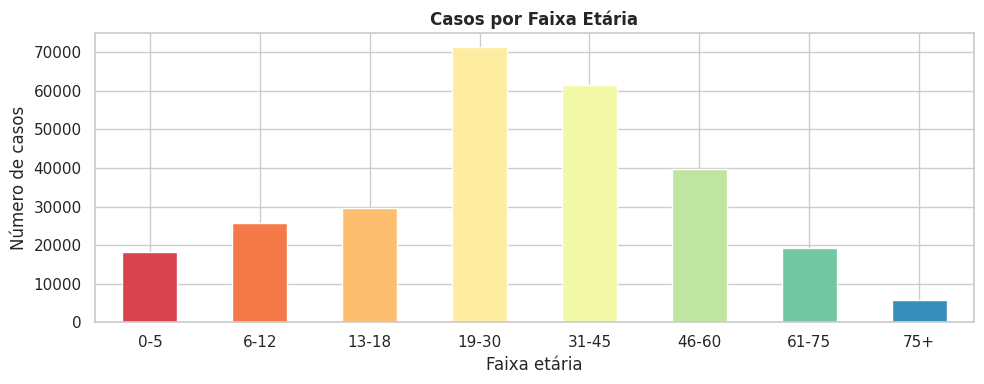

Média de idade: 31.8 anos
Mediana de idade: 29.0 anos


In [14]:


# Converter idade
def decode_age(val):

    try:
        v = int(val)

        if v >= 4000:
            return v - 4000

        elif v >= 3000:
            return (v - 3000) / 12

        elif v >= 2000:
            return (v - 2000) / 365

        else:
            return 0

    except:
        return np.nan

df['IDADE_ANOS'] = df['NU_IDADE_N'].apply(decode_age)

# Filtrar idades válidas
df_idade = df[df['IDADE_ANOS'].between(0, 110)]

# Criar faixas
faixas = pd.cut(
    df_idade['IDADE_ANOS'],
    bins=[0,5,12,18,30,45,60,75,110],
    labels=[
        '0-5','6-12','13-18',
        '19-30','31-45',
        '46-60','61-75','75+'
    ]
)

faixa_count = faixas.value_counts().sort_index()

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))

faixa_count.plot(
    kind='bar',
    color=sns.color_palette('Spectral',
                            len(faixa_count)),
    ax=ax,
    rot=0
)

ax.set_xlabel('Faixa etária')
ax.set_ylabel('Número de casos')

ax.set_title('Casos por Faixa Etária',
             fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Média de idade: {df_idade["IDADE_ANOS"].mean():.1f} anos')
print(f'Mediana de idade: {df_idade["IDADE_ANOS"].median():.1f} anos')

## Análise Temporal das Notificações

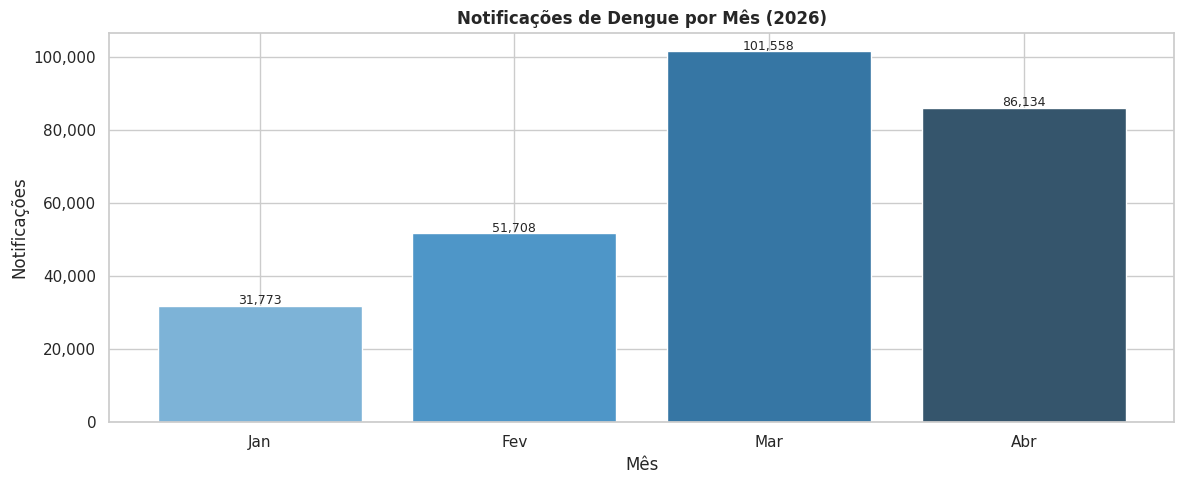

Mês com maior número de notificações: Mar


In [8]:
# Conversão da data
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'],
                                  errors='coerce')

# Criar coluna do mês
df['MES_NOT'] = df['DT_NOTIFIC'].dt.month

# Quantidade por mês
por_mes = df['MES_NOT'].value_counts().sort_index()

meses = ['Jan','Fev','Mar','Abr',
         'Mai','Jun','Jul','Ago',
         'Set','Out','Nov','Dez']

# Gráfico
fig, ax = plt.subplots()

bars = ax.bar(por_mes.index,
              por_mes.values,
              color=sns.color_palette('Blues_d',
                                      len(por_mes)))

ax.set_xticks(por_mes.index)
ax.set_xticklabels([meses[i-1] for i in por_mes.index])

ax.set_xlabel('Mês')
ax.set_ylabel('Notificações')

ax.set_title('Notificações de Dengue por Mês (2026)',
             fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Valores nas barras
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'{int(bar.get_height()):,}',
            ha='center',
            fontsize=9)

plt.tight_layout()
plt.show()

print(f"Mês com maior número de notificações: {meses[por_mes.idxmax()-1]}")

## Correlação Entre Hospitalização e Faixa Etária

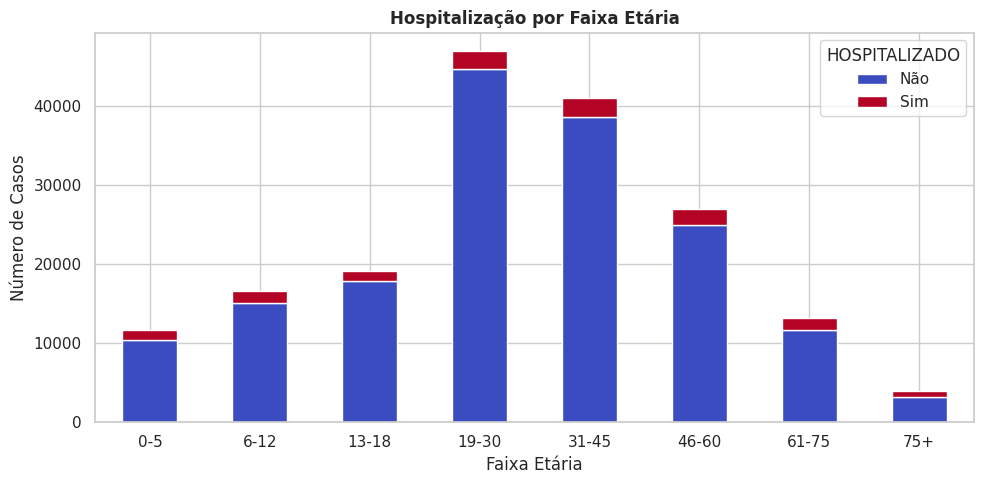

In [15]:
# Criar variável de hospitalização
df_hosp = df.copy()

df_hosp['HOSPITALIZADO'] = df_hosp['HOSPITALIZ'].map({
    1: 'Sim',
    2: 'Não'
})

# Faixas etárias
faixas = pd.cut(
    df_hosp['IDADE_ANOS'],
    bins=[0,5,12,18,30,45,60,75,110],
    labels=['0-5','6-12','13-18','19-30',
            '31-45','46-60','61-75','75+']
)

df_hosp['FAIXA_ETARIA'] = faixas

# Tabela cruzada
cross = pd.crosstab(
    df_hosp['FAIXA_ETARIA'],
    df_hosp['HOSPITALIZADO']
)

# Gráfico
cross.plot(kind='bar',
           stacked=True,
           figsize=(10,5),
           colormap='coolwarm')

plt.title('Hospitalização por Faixa Etária',
          fontweight='bold')

plt.xlabel('Faixa Etária')
plt.ylabel('Número de Casos')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Evolução dos Casos ao Longo das Semanas Epidemiológicas

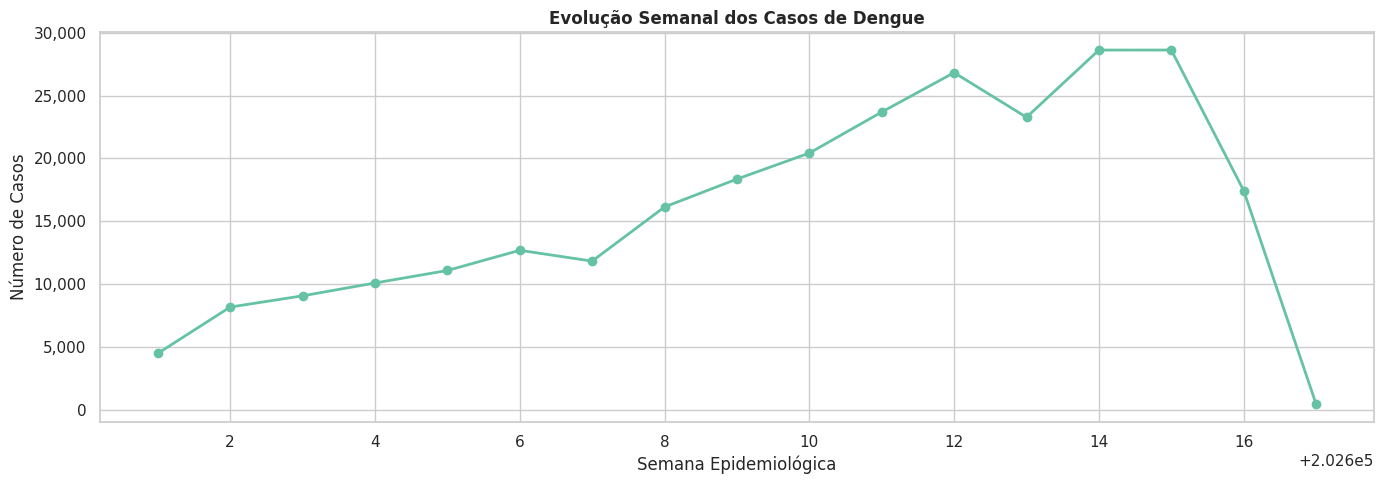

In [16]:
# Casos por semana epidemiológica
semana = df['SEM_NOT'].value_counts().sort_index()

# Gráfico
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(semana.index,
        semana.values,
        marker='o',
        linewidth=2)

ax.set_title('Evolução Semanal dos Casos de Dengue',
             fontweight='bold')

ax.set_xlabel('Semana Epidemiológica')
ax.set_ylabel('Número de Casos')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

## Comparação Entre Casos Graves e Não Graves

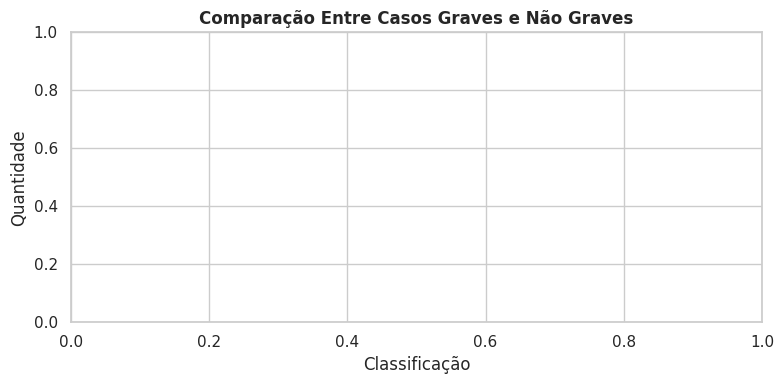

In [17]:
# Criar variável de gravidade
grave = df['CLASSI_FIN'].map({
    1:'Clássica',
    2:'Com complicação',
    3:'Grave'
})

grave_count = grave.value_counts()

# Gráfico
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(
    x=grave_count.index,
    y=grave_count.values,
    palette='Reds',
    ax=ax
)

ax.set_title('Comparação Entre Casos Graves e Não Graves',
             fontweight='bold')

ax.set_xlabel('Classificação')
ax.set_ylabel('Quantidade')

plt.tight_layout()
plt.show()